# FORGE Analytics — Scenario Analysis
### Notebook 4 of 4 · Antonio Heredia · FP&A Portfolio

The previous notebooks show what happened. This one asks what could happen.

I built three revenue scenarios with upside, base, and downside, using 
different assumptions about growth and churn. The goal is to understand 
the range of outcomes FORGE could face over the next 12 months depending 
on how the business performs.

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Connect to FORGE database
conn = sqlite3.connect('../data/forge.db')

# Load the last 6 months of actual revenue as our baseline
baseline = pd.read_sql_query("""
    SELECT 
        month,
        SUM(revenue) as total_revenue,
        COUNT(DISTINCT customer_id) as active_customers
    FROM revenue_transactions
    GROUP BY month
    ORDER BY month ASC
""", conn)

baseline['month'] = pd.to_datetime(baseline['month'])

# Get the last actual month and revenue
last_month = baseline['month'].iloc[-1]
last_revenue = baseline['total_revenue'].iloc[-1]
last_customers = baseline['active_customers'].iloc[-1]

print(f"Baseline — last actual month: {last_month.strftime('%b %Y')}")
print(f"Last actual monthly revenue:  ${last_revenue:,.0f}")
print(f"Active customers:             {last_customers}")
print(f"\nThis is our starting point for all three scenarios.")

Baseline — last actual month: Mar 2026
Last actual monthly revenue:  $1,447,535
Active customers:             438

This is our starting point for all three scenarios.


## Step 1 — Scenario assumptions

Each scenario uses a different monthly growth rate and churn rate. 
These are the two levers that matter most in a SaaS business.
How fast you acquire revenue and how fast you lose it.

In [4]:
# Define the three scenarios
scenarios = {
    'Upside': {
        'monthly_growth_rate': 0.025,   # 2.5% monthly revenue growth
        'churn_rate': 0.02,              # 2% monthly churn
        'color': '#1D9E75',
        'description': 'Accelerated acquisition, improved retention'
    },
    'Base': {
        'monthly_growth_rate': 0.008,   # 0.8% monthly growth (current trend)
        'churn_rate': 0.04,              # 4% monthly churn
        'color': '#185FA5',
        'description': 'Current trend continues'
    },
    'Downside': {
        'monthly_growth_rate': -0.005,  # -0.5% monthly decline
        'churn_rate': 0.08,              # 8% monthly churn
        'color': '#E24B4A',
        'description': 'Growth stalls, churn increases'
    }
}

print("Scenario assumptions:")
print(f"{'Scenario':<12} {'Monthly Growth':>15} {'Churn Rate':>12} {'Description'}")
print("-" * 70)
for name, s in scenarios.items():
    print(f"{name:<12} {s['monthly_growth_rate']:>14.1%} {s['churn_rate']:>11.1%}  {s['description']}")

Scenario assumptions:
Scenario      Monthly Growth   Churn Rate Description
----------------------------------------------------------------------
Upside                 2.5%        2.0%  Accelerated acquisition, improved retention
Base                   0.8%        4.0%  Current trend continues
Downside              -0.5%        8.0%  Growth stalls, churn increases


## Step 2 — 12-month revenue projection

Starting from March 2026 actual revenue of $1.45M, I project 
each scenario forward 12 months. Growth adds revenue, churn 
removes it. The net result depends on which force is stronger.

In [5]:
from datetime import datetime
import pandas as pd

# Project 12 months forward for each scenario
projection_months = 12
results = {}

for scenario_name, params in scenarios.items():
    monthly_revenues = []
    current_revenue = last_revenue
    
    for month in range(1, projection_months + 1):
        # Apply churn to existing revenue
        retained_revenue = current_revenue * (1 - params['churn_rate'])
        # Apply growth (new revenue coming in)
        new_revenue = current_revenue * params['monthly_growth_rate']
        # Net revenue for this month
        current_revenue = retained_revenue + abs(new_revenue) if params['monthly_growth_rate'] >= 0 else retained_revenue + new_revenue
        monthly_revenues.append(round(current_revenue, 2))
    
    # Create month labels
    future_months = pd.date_range(
        start=last_month + pd.DateOffset(months=1), 
        periods=projection_months, 
        freq='MS'
    )
    
    results[scenario_name] = pd.DataFrame({
        'month': future_months,
        'revenue': monthly_revenues,
        'scenario': scenario_name
    })

# Print summary table
print(f"{'Month':<12}", end='')
for name in scenarios.keys():
    print(f"{name:>14}", end='')
print()
print("-" * 54)

for i in range(projection_months):
    month_label = results['Upside']['month'].iloc[i].strftime('%b %Y')
    print(f"{month_label:<12}", end='')
    for name in scenarios.keys():
        rev = results[name]['revenue'].iloc[i]
        print(f"  ${rev:>10,.0f}", end='')
    print()

Month               Upside          Base      Downside
------------------------------------------------------
Apr 2026      $ 1,454,772  $ 1,401,214  $ 1,324,494
May 2026      $ 1,462,046  $ 1,356,375  $ 1,211,912
Jun 2026      $ 1,469,356  $ 1,312,971  $ 1,108,900
Jul 2026      $ 1,476,703  $ 1,270,956  $ 1,014,643
Aug 2026      $ 1,484,087  $ 1,230,285  $   928,399
Sep 2026      $ 1,491,507  $ 1,190,916  $   849,485
Oct 2026      $ 1,498,965  $ 1,152,807  $   777,278
Nov 2026      $ 1,506,460  $ 1,115,917  $   711,210
Dec 2026      $ 1,513,992  $ 1,080,208  $   650,757
Jan 2027      $ 1,521,562  $ 1,045,641  $   595,443
Feb 2027      $ 1,529,170  $ 1,012,180  $   544,830
Mar 2027      $ 1,536,815  $   979,791  $   498,519


## Step 3 — Scenario chart

The vertical line marks today. Everything to the left is actual. 
Everything to the right is projected under each scenario.

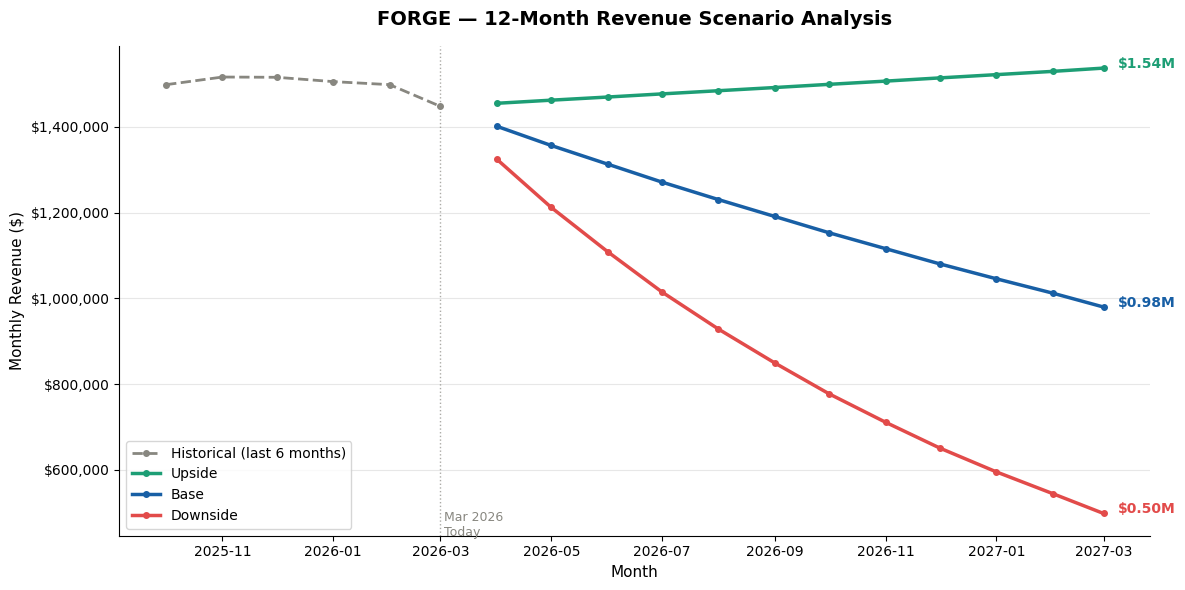

Chart saved.


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot historical revenue (last 6 months)
historical = baseline.tail(6)
ax.plot(historical['month'], historical['total_revenue'],
        color='#888780', linewidth=2, linestyle='--',
        marker='o', markersize=4, label='Historical (last 6 months)')

# Plot each scenario
for scenario_name, params in scenarios.items():
    df = results[scenario_name]
    ax.plot(df['month'], df['revenue'],
            color=params['color'], linewidth=2.5,
            marker='o', markersize=4, label=scenario_name)
    # Add end value label
    ax.annotate(f"${df['revenue'].iloc[-1]/1e6:.2f}M",
                xy=(df['month'].iloc[-1], df['revenue'].iloc[-1]),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, fontweight='bold',
                color=params['color'])

# Add vertical line at today
ax.axvline(x=last_month, color='#888780', linewidth=1, 
           linestyle=':', alpha=0.7)
ax.text(last_month, ax.get_ylim()[0], ' Mar 2026\n Today', 
        fontsize=9, color='#888780')

ax.set_title('FORGE — 12-Month Revenue Scenario Analysis', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Monthly Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/scenario_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Step 4 — ARR impact

Converting monthly revenue to ARR makes the stakes clearer. 
The difference between upside and downside is over $12M in 
annualized revenue from the exact same starting point.

In [7]:
print("=" * 55)
print("FORGE — 12-Month Scenario Summary")
print("=" * 55)

current_arr = last_revenue * 12
print(f"\nCurrent ARR (Mar 2026):  ${current_arr:>12,.0f}")
print()

print(f"{'Scenario':<12} {'Mar 2027 MRR':>14} {'Mar 2027 ARR':>14} {'ARR Change':>12}")
print("-" * 55)

for name, params in scenarios.items():
    end_mrr = results[name]['revenue'].iloc[-1]
    end_arr = end_mrr * 12
    arr_change = end_arr - current_arr
    arrow = "↑" if arr_change > 0 else "↓"
    print(f"{name:<12} ${end_mrr:>12,.0f}  ${end_arr:>12,.0f}  {arrow} ${abs(arr_change):>9,.0f}")

print()
print(f"Revenue range at Month 12:")
upside_end = results['Upside']['revenue'].iloc[-1]
downside_end = results['Downside']['revenue'].iloc[-1]
print(f"  Best case:  ${upside_end:,.0f}/month")
print(f"  Worst case: ${downside_end:,.0f}/month")
print(f"  Gap:        ${upside_end - downside_end:,.0f}/month  (${(upside_end-downside_end)*12:,.0f} annualized)")

FORGE — 12-Month Scenario Summary

Current ARR (Mar 2026):  $  17,370,416

Scenario       Mar 2027 MRR   Mar 2027 ARR   ARR Change
-------------------------------------------------------
Upside       $   1,536,815  $  18,441,785  ↑ $1,071,369
Base         $     979,791  $  11,757,487  ↓ $5,612,929
Downside     $     498,519  $   5,982,233  ↓ $11,388,183

Revenue range at Month 12:
  Best case:  $1,536,815/month
  Worst case: $498,519/month
  Gap:        $1,038,296/month  ($12,459,552 annualized)


## Key findings

The base case is the most important scenario to focus on and not the downside.

If current trends continue without any intervention, FORGE projects 
to lose nearly a third of its monthly revenue over 12 months, dropping 
from $1.45M to $0.98M. That is not an extreme scenario, it is simply 
what happens when churn slightly outpaces new customer acquisition over time.

The gap between upside and downside at month 12 is $1.04M per month — 
$12.5M annualized — driven entirely